# 1. Initialisation et Configuration

In [3]:
# Absolute path: /home/LabLog635/Laboratoire2.ipynb
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import random
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.base import clone

# 2. Prétraitement et partitionnement des données

In [ ]:
input_dir = "EnsembleB"                
output_dir = "EnsembleB_split"    

train_ratio = 0.6
val_ratio = 0.2

random.seed(42)

classes = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))]

for cls in classes:
    src_cls_dir = os.path.join(input_dir, cls)
    images = [f for f in os.listdir(src_cls_dir) if f.lower().endswith(".png")]
    
    random.shuffle(images)
    
    n = len(images)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    
    train_imgs = images[:n_train]
    val_imgs = images[n_train:n_train + n_val]
    test_imgs = images[n_train + n_val:]
    
    # créer dossiers de sortie
    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)
    
    # copier
    for img in train_imgs:
        shutil.copy(os.path.join(src_cls_dir, img),
                    os.path.join(output_dir, "train", cls, img))
        
    for img in val_imgs:
        shutil.copy(os.path.join(src_cls_dir, img),
                    os.path.join(output_dir, "val", cls, img))
        
    for img in test_imgs:
        shutil.copy(os.path.join(src_cls_dir, img),
                    os.path.join(output_dir, "test", cls, img))

print("Fini")

Fini


In [11]:
REDUCED_WIDTH = 160
REDUCED_HEIGHT = 120

ROI_WIDTH = 128
ROI_HEIGHT = 128

def extract_roi_with_resize_first(image_path, debug=False):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Impossible de lire l'image: {image_path}")

    original = image.copy()

    # reduction d'image  
    resized = cv2.resize(image, (REDUCED_WIDTH, REDUCED_HEIGHT))

    # niveau de gris 
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    # light blur 
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # binarisation
    _, thresh = cv2.threshold(blurred, 180, 255, cv2.THRESH_BINARY_INV)

    # contours externes
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        raise ValueError(f"Aucun contour trouvé pour: {image_path}")

    # bigger contours
    largest_contour = max(contours, key=cv2.contourArea)

    # rectangle 
    x, y, w, h = cv2.boundingRect(largest_contour)

    # padding 
    pad = 4
    x = max(0, x - pad)
    y = max(0, y - pad)
    w = min(resized.shape[1] - x, w + 2 * pad)
    h = min(resized.shape[0] - y, h + 2 * pad)

    # extraction ROI
    roi = resized[y:y+h, x:x+w]
    # conversion grayscale 
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    # taille fixe pr le classification
    roi_final = cv2.resize(roi_gray, (ROI_WIDTH, ROI_HEIGHT))

    if debug:
        plt.figure(figsize=(14, 4))

        plt.subplot(1, 4, 1)
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        plt.title("Originale 320x240")
        plt.axis("off")
    
        plt.subplot(1, 4, 2)
        plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
        plt.title("Réduite 160x120")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(thresh, cmap="gray")
        plt.title("Threshold")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(roi_final, cmap="gray")
        plt.title("ROI final 128x128")
        plt.axis("off")

        plt.show()

    return roi_final

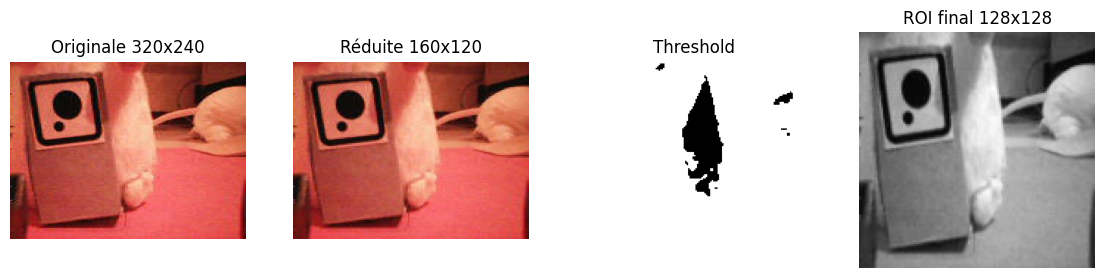

(128, 128)


In [15]:
#run le ROI sur une seule image pour tester si sa marche bien
sample_path = os.path.join("EnsembleB_split", "train", "Cercle2", "3_Cercle2.png")
roi = extract_roi_with_resize_first(sample_path, debug=True)
print(roi.shape)

In [16]:
#on run le ROI sur tout le fichier ensemble B et on le store 
input_root = "EnsembleB_split"
output_root = "EnsembleB_roi"

splits = ["train", "val", "test"]

for split in splits:
    split_input = os.path.join(input_root, split)
    split_output = os.path.join(output_root, split)
    
    os.makedirs(split_output, exist_ok=True)

    for class_name in os.listdir(split_input):
        class_input = os.path.join(split_input, class_name)
        class_output = os.path.join(split_output, class_name)

        if not os.path.isdir(class_input):
            continue

        os.makedirs(class_output, exist_ok=True)

        for img_name in os.listdir(class_input):
            img_input_path = os.path.join(class_input, img_name)
            img_output_path = os.path.join(class_output, img_name)

            try:
                roi = extract_roi_with_resize_first(img_input_path, debug=False)
                cv2.imwrite(img_output_path, roi)
            except Exception as e:
                print(f"Erreur avec {img_input_path}: {e}")

print("Prétraitement terminé.")

Prétraitement terminé.


In [17]:
# etape 4 : extraction des caracteristiques
def load_roi_dataset(folder):
    X = []
    y = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                print(f"Image illisible ignorée: {img_path}")
                continue

            # in case qu'une image na pas exactement la bonne taille
            img = cv2.resize(img, (128, 128))

            # normalisation entre 0 et 1
            img = img.astype(np.float32) / 255.0

            # flatten vecteur de 16384 pixels
            X.append(img.flatten())
            y.append(class_name)

    return np.array(X), np.array(y), class_names

In [18]:
# on charge train/val/test pour l'extraction des caracteristiques
base_dir = "EnsembleB_roi"

X_train, y_train, class_names = load_roi_dataset(os.path.join(base_dir, "train"))
X_val, y_val, _ = load_roi_dataset(os.path.join(base_dir, "val"))
X_test, y_test, _ = load_roi_dataset(os.path.join(base_dir, "test"))

print("Classes :", class_names)
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)
print("X_val   :", X_val.shape)
print("y_val   :", y_val.shape)
print("X_test  :", X_test.shape)
print("y_test  :", y_test.shape)

Classes : ['Cercle2', 'Cercle3', 'Cercle4', 'Diamant2', 'Diamant4', 'Hexagone2', 'Hexagone4', 'Triangle2', 'Triangle4', 'Triangle5']
X_train : (5398, 16384)
y_train : (5398,)
X_val   : (1796, 16384)
y_val   : (1796,)
X_test  : (1809, 16384)
y_test  : (1809,)


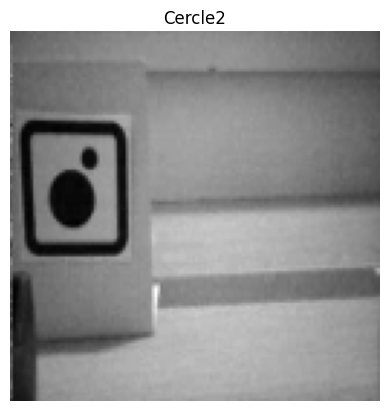

In [19]:
#Affiche une image traiter comme exemple pour make sure que sa a bien marcher 
idx = 0
img = X_train[idx].reshape(128, 128)

plt.imshow(img, cmap="gray")
plt.title(y_train[idx])
plt.axis("off")
plt.show()

# 3. Chargement et normalisation du dataset

In [4]:
# reglage des chemin et des classe
BASE_PATH = "EnsembleB_roi"
CLASSES = ["Cercle2", "Cercle3", "Cercle4", "Diamant2", "Diamant4", 
           "Hexagone2", "Hexagone4", "Triangle2", "Triangle4", "Triangle5"]
IMG_SIZE = 128 
INPUT_SIZE = IMG_SIZE * IMG_SIZE

class_to_idx = {name: i for i, name in enumerate(CLASSES)}

def load_roi_dataset(split_folder):
    X = []
    y = []
    
    # on boucle sur les dossier de chaque forme
    for class_name in CLASSES:
        class_path = os.path.join(split_folder, class_name)
        if not os.path.exists(class_path):
            continue
            
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None:
                # on aplatit et on normalise entre 0 et 1
                X.append(img.flatten() / 255.0)
                # on garde l'indice de la classe
                y.append(class_to_idx[class_name])
                
    return np.array(X), np.array(y)

# chargement des donnée
print("chargement des image depuis le dossier roi...")

# on prend les split train val test direct dans les dossier
X_train, y_train = load_roi_dataset(os.path.join(BASE_PATH, "train"))
X_val, y_val     = load_roi_dataset(os.path.join(BASE_PATH, "val"))
X_test, y_test   = load_roi_dataset(os.path.join(BASE_PATH, "test"))

# scale des donnée pour pas que le modele plante
scaler = StandardScaler()

# on fit sur le train et on aplique au reste
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("data est prete")
print(f"ya {len(CLASSES)} classe au total")
print(f"train : {X_train_scaled.shape[0]} image")
print(f"val : {X_val_scaled.shape[0]} image")
print(f"test : {X_test_scaled.shape[0]} image")

chargement des image depuis le dossier roi...
data est prete
ya 10 classe au total
train : 5398 image
val : 1796 image
test : 1809 image


# 4. Implémentation du réseau de neurones

In [5]:
class NeuralNetworkScratch:
    def __init__(self, n_x, n_h, n_y, lr=0.01):
        self.lr = lr
        # init de he pour relu
        self.W1 = np.random.randn(n_h, n_x) * np.sqrt(2./n_x)
        self.b1 = np.zeros((n_h, 1))
        self.W2 = np.random.randn(n_y, n_h) * np.sqrt(1./n_h)
        self.b2 = np.zeros((n_y, 1))

    def relu(self, Z): return np.maximum(0, Z)
    def relu_deriv(self, Z): return Z > 0
    
    def softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return expZ / np.sum(expZ, axis=0, keepdims=True)

    def forward(self, X):
        # x c'est les caracteristique et les samples
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def backward(self, X, Y):
        m = X.shape[1]
        dZ2 = self.A2 - Y # y doit etre en one hot sinon ca marche pas
        dW2 = (1/m) * np.dot(dZ2, self.A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
        
        dZ1 = np.dot(self.W2.T, dZ2) * self.relu_deriv(self.Z1)
        dW1 = (1/m) * np.dot(dZ1, X.T)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        # on update les poid et les biais avec le lr
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def predict(self, X):
        A2 = self.forward(X)
        return np.argmax(A2, axis=0)

Y_train_oh = np.eye(len(CLASSES))[y_train].T

# 5. Apprentissage, évaluation comparative et analyse de scalabilité


--- ANALYSE POUR 80% DES DONNÉES ---


<Figure size 700x500 with 0 Axes>

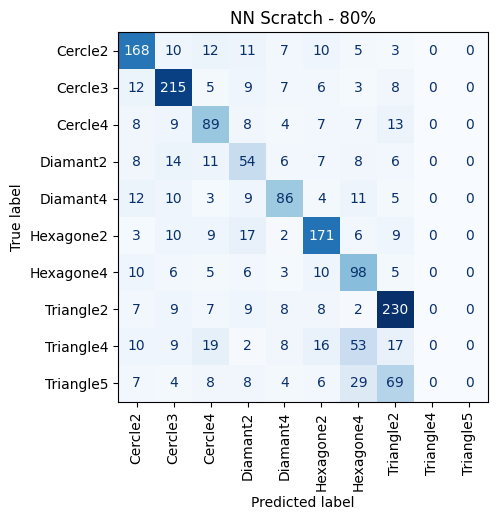

<Figure size 700x500 with 0 Axes>

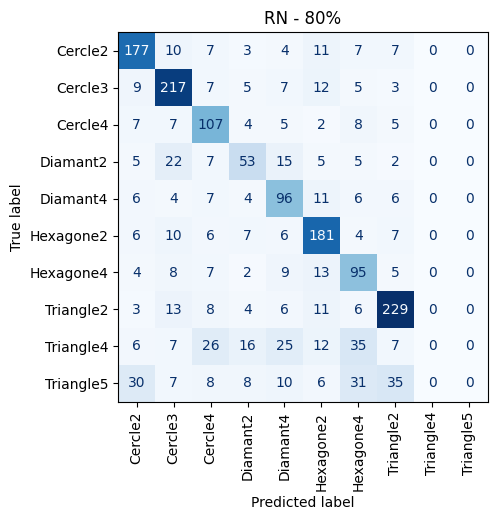

<Figure size 700x500 with 0 Axes>

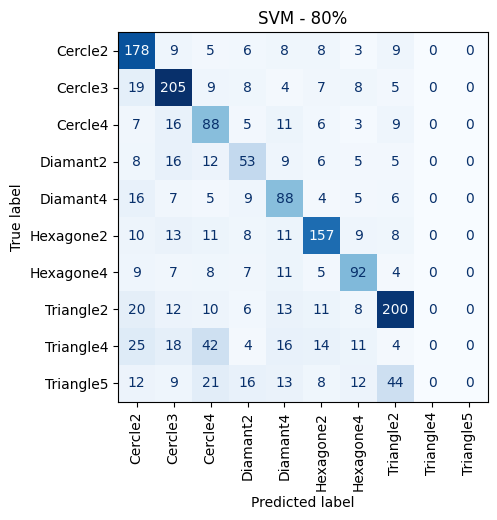

<Figure size 700x500 with 0 Axes>

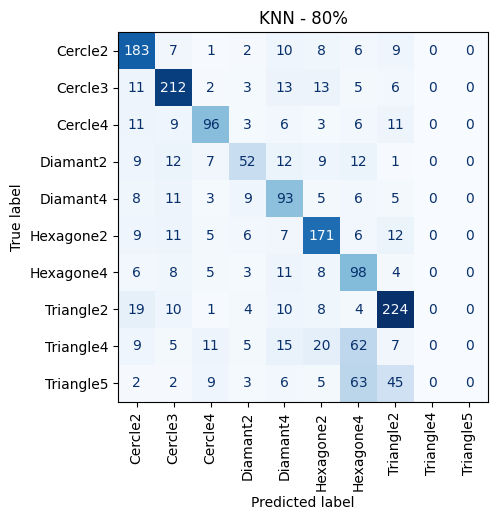


--- ANALYSE POUR 60% DES DONNÉES ---


<Figure size 700x500 with 0 Axes>

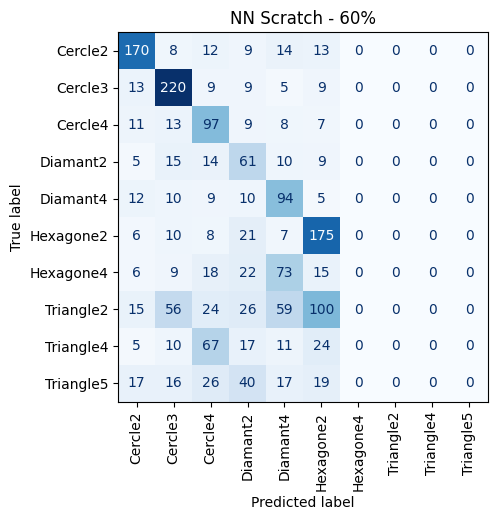

<Figure size 700x500 with 0 Axes>

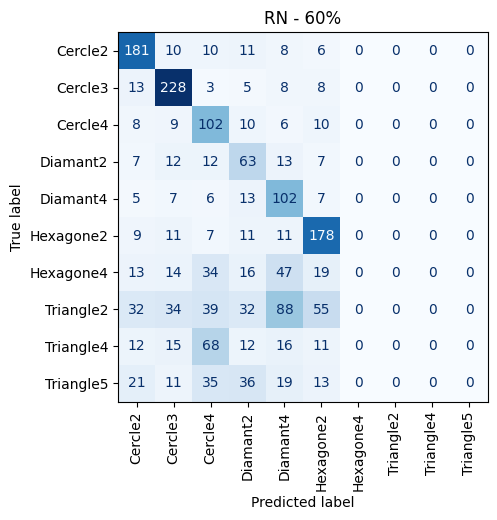

<Figure size 700x500 with 0 Axes>

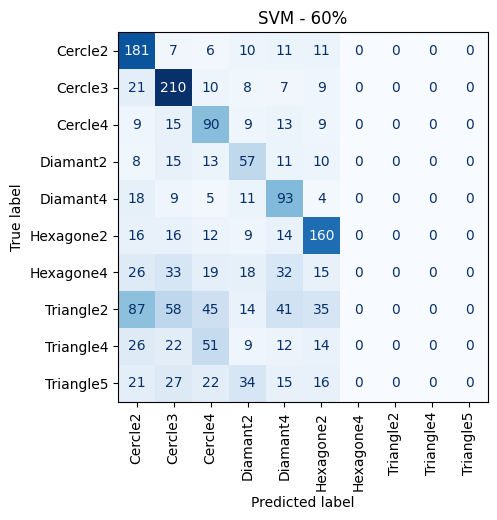

<Figure size 700x500 with 0 Axes>

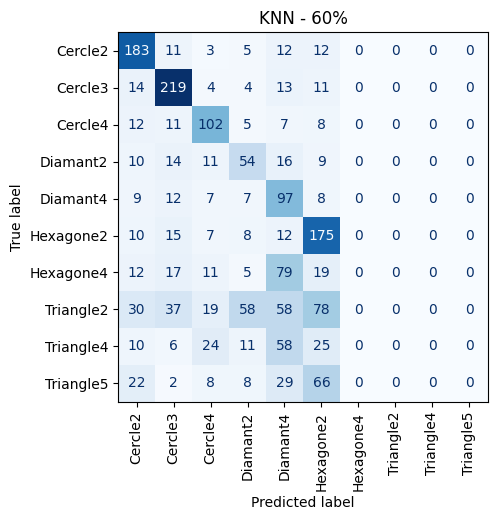


--- ANALYSE POUR 40% DES DONNÉES ---


<Figure size 700x500 with 0 Axes>

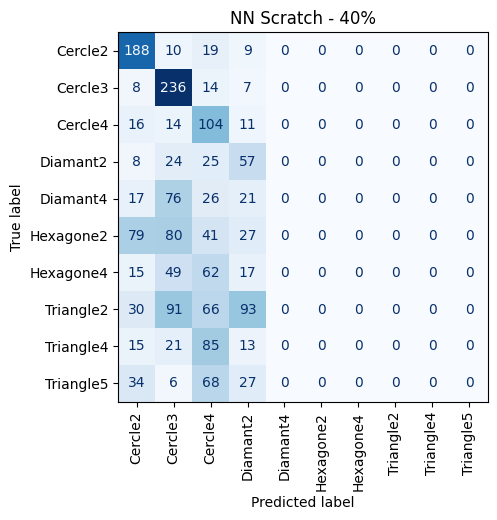

<Figure size 700x500 with 0 Axes>

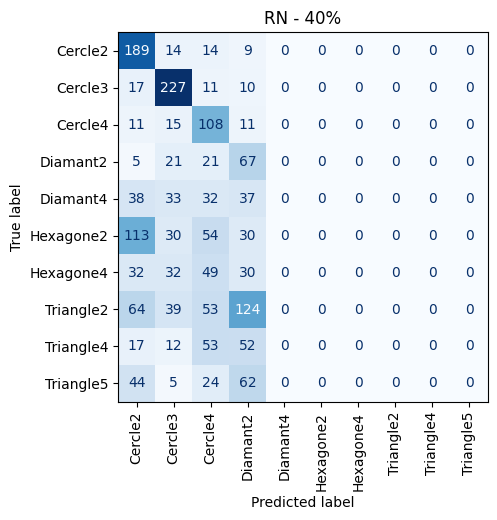

<Figure size 700x500 with 0 Axes>

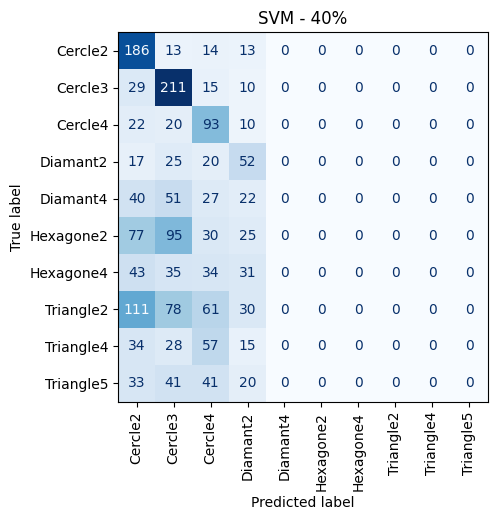

<Figure size 700x500 with 0 Axes>

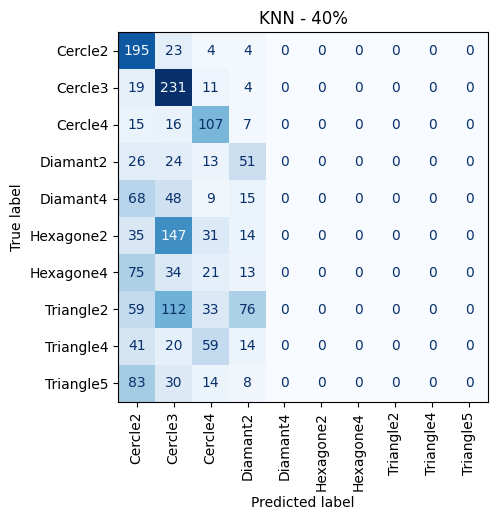


--- ANALYSE POUR 20% DES DONNÉES ---


<Figure size 700x500 with 0 Axes>

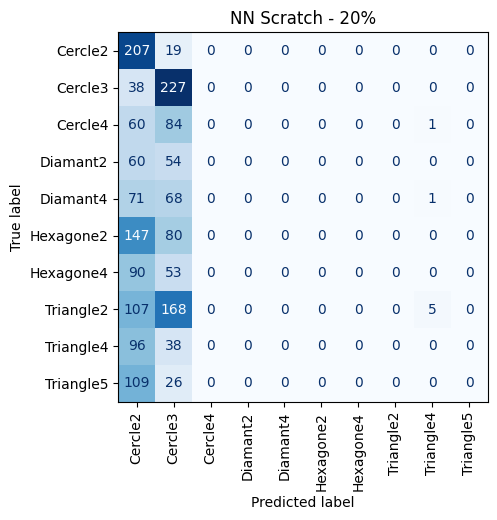

<Figure size 700x500 with 0 Axes>

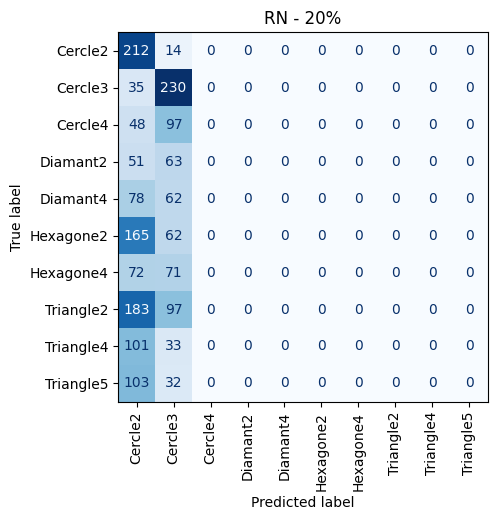

<Figure size 700x500 with 0 Axes>

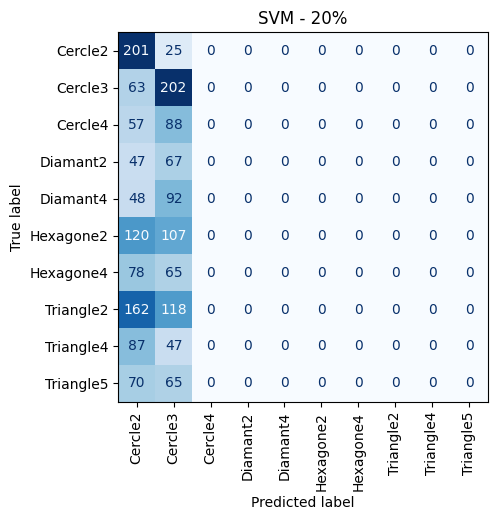

<Figure size 700x500 with 0 Axes>

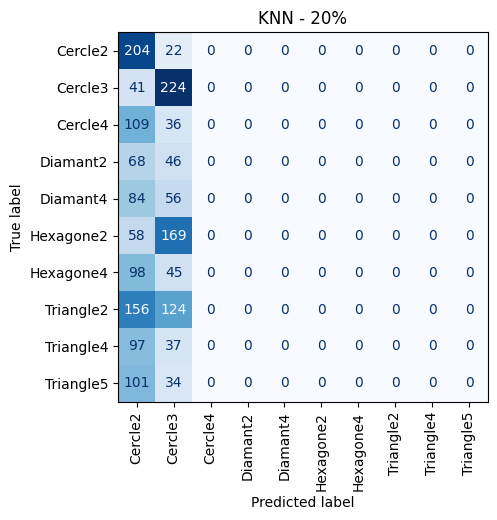


--- FIN DU TRAITEMENT ---
    Pct      Modèle       Acc      Prec       Rec        F1     T_Train  \
0   0.8  NN_scratch  0.614151  0.529432  0.614151  0.566705   54.246063   
1   0.8          RN  0.638474  0.547916  0.638474  0.588459   35.522641   
2   0.8         SVM  0.586512  0.506306  0.586512  0.541466  569.741181   
3   0.8         KNN  0.624102  0.546285  0.624102  0.578432    0.098797   
4   0.6  NN_scratch  0.451631  0.296853  0.451631  0.354433   25.884113   
5   0.6          RN  0.472084  0.311107  0.472084  0.371354   35.481239   
6   0.6         SVM  0.437258  0.275761  0.437258  0.336429  313.159307   
7   0.6         KNN  0.458817  0.302007  0.458817  0.360350    0.038584   
8   0.4  NN_scratch  0.323383  0.143323  0.323383  0.196746   20.191815   
9   0.4          RN  0.326700  0.152679  0.326700  0.204598   18.163675   
10  0.4         SVM  0.299613  0.124415  0.299613  0.175457  126.807931   
11  0.4         KNN  0.322830  0.132949  0.322830  0.187567    0.038770  

In [9]:
def evaluate_model(name, model, X_t, y_t):
    start_time = time.time()
    if name == "Scratch":
        preds = model.predict(X_t.T)
    else:
        preds = model.predict(X_t)
    pred_time = time.time() - start_time
    return accuracy_score(y_t, preds), pred_time, classification_report(y_t, preds, target_names=CLASSES)

percentages = [0.8, 0.6, 0.4, 0.2]
all_results = [] 

sklearn_models = {
    "RN": MLPClassifier(hidden_layer_sizes=(128,), max_iter=200),
    "SVM": SVC(kernel='linear'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

for pct in percentages:
    p_val = int(pct*100)
    print(f"\n--- ANALYSE POUR {p_val}% DES DONNÉES ---")
    
    idx = int(len(X_train_scaled) * pct)
    X_sub, y_sub = X_train_scaled[:idx], y_train[:idx]
    y_sub_oh = np.eye(len(CLASSES))[y_sub].T 
    
    # --- MODELE SCRATCH ---
    start_train = time.time()
    model_s = NeuralNetworkScratch(INPUT_SIZE, 128, len(CLASSES), lr=0.01)
    for epoch in range(200):
        model_s.forward(X_sub.T)
        model_s.backward(X_sub.T, y_sub_oh)
    t_train_s = time.time() - start_train
    
    start_pred = time.time()
    preds_s = model_s.predict(X_test_scaled.T)
    t_pred_s = time.time() - start_pred
    
    acc_s = accuracy_score(y_test, preds_s)
    p_s, r_s, f_s, _ = precision_recall_fscore_support(y_test, preds_s, average='weighted', zero_division=0)
    
    all_results.append({
        "Pct": pct, "Modèle": "NN_scratch", "Acc": acc_s, 
        "Prec": p_s, "Rec": r_s, "F1": f_s,
        "T_Train": t_train_s, "T_Pred": t_pred_s
    })
    
    plt.figure(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, preds_s), display_labels=CLASSES)
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(f"NN Scratch - {p_val}%")
    plt.xticks(rotation=90)
    plt.savefig(f"{p_val}_scratch.png")
    plt.show()
    plt.close()

    # --- AUTRES MODELES ---
    for name, clf_orig in sklearn_models.items():
        model = clone(clf_orig)
        
        start_train = time.time()
        model.fit(X_sub, y_sub)
        t_train = time.time() - start_train
        
        start_pred = time.time()
        preds = model.predict(X_test_scaled)
        t_pred = time.time() - start_pred
        
        acc = accuracy_score(y_test, preds)
        p, r, f, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
        
        all_results.append({
            "Pct": pct, "Modèle": name, "Acc": acc, 
            "Prec": p, "Rec": r, "F1": f,
            "T_Train": t_train, "T_Pred": t_pred
        })
        
        # Affichage et sauvegarde pour RN, SVM, KNN
        plt.figure(figsize=(7, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=CLASSES)
        disp.plot(cmap='Blues', colorbar=False)
        plt.title(f"{name} - {p_val}%")
        plt.xticks(rotation=90)
        plt.savefig(f"{p_val}_{name}.png")
        plt.show()
        plt.close()

print("\n--- FIN DU TRAITEMENT ---")
df_final = pd.DataFrame(all_results)
df_final.to_csv("resultats_complets.csv", index=False)
print(df_final)